In [98]:
import requests
import subprocess
import sys
import os
from urllib.request import urlretrieve
from zipfile import ZipFile

# Function to download the file from Google Drive
def download_file_from_google_drive(file_id, destination):
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    response = requests.get(url)
    if response.status_code == 200:
        with open(destination, 'wb') as f:
            f.write(response.content)
        print(f"{destination} downloaded successfully.")
    else:
        print(f"Failed to download {destination}.")

# Download the requirements.txt file from Google Drive
file_id = "1e8vmGO8Z9g-QoDW9N5u9jACtx_qCVuM5"
destination = "requirements.txt"
download_file_from_google_drive(file_id, destination)

# Function to install missing packages
def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Read the requirements.txt file and store libraries with their versions
libraries = {}

with open('requirements.txt', 'r') as f:
    for line in f:
        # Each line in the file is in the form 'library==version'
        if '==' in line:
            lib, version = line.strip().split('==')
            libraries[lib] = version

# Standard libraries that do not require installation
standard_libraries = [
    'os', 'zipfile', 'urllib', 'csv', 'math'
]

# Check third-party libraries and install them if missing
for lib, version in libraries.items():
    try:
        __import__(lib)
        print(f"{lib} is already installed.")
    except ImportError:
        print(f"{lib} not found. Installing...")
        install_package(f"{lib}=={version}")

# Confirm standard libraries are available (they should be, as they are part of Python)
for lib in standard_libraries:
    try:
        __import__(lib)
        print(f"Standard library {lib} is available.")
    except ImportError:
        print(f"Standard library {lib} not found, but it should be included in the Python standard library.")

# Import the third-party libraries with shorthand notations
import requests
import pandas as pd
import numpy as np
import altair as alt
from vega_datasets import data
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from scipy.stats import t

requirements.txt downloaded successfully.
requests is already installed.
pandas is already installed.
numpy is already installed.
altair is already installed.
vega_datasets is already installed.
scikit-learn not found. Installing...
seaborn is already installed.
matplotlib is already installed.
statsmodels is already installed.
scipy is already installed.
Standard library os is available.
Standard library zipfile is available.
Standard library urllib is available.
Standard library csv is available.
Standard library math is available.


In [99]:
def download_file(download_f, filename, force=False):
    """
    Downloads a file using a dynamic function.

    :param download_f: Function to be used for the actual download operation
    :param filename: File name for saving
    :param force: Whether to overwrite an existing file
    """
    if force or not os.path.exists(filename):
        download_f(filename)

In [100]:
def download_cdc_survey(filename):
    """
    Downloads the cdc survey dataset.

    :param filename: File name for saving
    """
    def download(filename):
        """
        Actual download logic for the personal cdc survey dataset

        :param filename: File name for saving
        """
        url = 'https://www.cdc.gov/brfss/annual_data/2022/files/LLCP2022ASC.zip'
        urlretrieve(url, filename)
    download_file(download, filename)
    with ZipFile(filename, 'r') as zObject:
        zObject.extractall(path='./cdc_survey_unzipped/')


In [101]:
def download_heart_disease_mortality_by_county(filename):
    """
    Downloads the mortality dataset.

    :param filename: File name for saving
    """
    def download(filename):
        """
        Actual download logic for the personal income dataset

        :param filename: File name for saving
        """
        url = 'https://data.cdc.gov/resource/jiwm-ppbh.csv?$limit=1000000'
        urlretrieve(url, filename)
    download_file(download, filename)


In [102]:
def download_covid_dataset(filename):
    """
    Downloads the CDC COVID-19 mortality dataset.

    :param filename: File name for saving
    """
    def download(filename):
        """
        Actual download logic for the CDC COVID-19 dataset.

        :param filename: File name for saving
        """
        url = 'https://data.cdc.gov/resource/hk9y-quqm.csv?$limit=1000000'
        urlretrieve(url, filename)

    download_file(download, filename)

In [103]:
heart_disease_mortality_by_county_csv_filename = 'mortality.csv'
download_heart_disease_mortality_by_county(heart_disease_mortality_by_county_csv_filename)

cdc_survey_zip_filename = 'cdc_survey.zip'
download_cdc_survey(cdc_survey_zip_filename)

covid_dataset_csv_filename = 'covid_mortality.csv'
download_covid_dataset(covid_dataset_csv_filename)

Add later for the parsing of the COVID dataset

In [104]:
state_code_to_abbr = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC', 12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN', 19: 'IA', 20: 'KS',
    21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY',
    37: 'NC', 38: 'ND', 39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC', 46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI', 56: 'WY'
    }

def parse_cdc_survey():
  """
  Reads the CDC survey input file and parses the contents using ASCII format.

  :return: CDC survey dataframe.
  """
  rows = []
  with open('./cdc_survey_unzipped/LLCP2022.ASC ', 'r') as f:
    count = 0
    for line in f:
      row = {}
      state_code = int(line[:2])
      interview_completed = line[31:35] == '1100'
      if interview_completed and state_code in state_code_to_abbr:
        row['State Abbr.'] = state_code_to_abbr[state_code]
        row['Interview Year'] = line[22:26]

        age_older_18_landline = line[67]
        if age_older_18_landline == '1':
          row['Is Adult Landline'] = True
        elif age_older_18_landline == '2':
          row['Is Adult Landline'] = False

        gender = line[1979]
        if gender == '1':
          row['Gender'] = 'Male'
        elif gender == '2':
          row['Gender'] = 'Female'

        num_of_adults_landline = line[69:71].strip()
        if num_of_adults_landline:
          row['Num of Adults Landline'] = int(num_of_adults_landline)


        age_older_18_cell = line[80]
        if age_older_18_cell == '1':
          row['Is Adult Cell'] = True

        num_of_adults_cell = line[88:90].strip()
        if num_of_adults_cell and int(num_of_adults_cell) <= 76:
          row['Num of Adults Cell'] = int(num_of_adults_cell)

        general_health = line[100].strip()
        if general_health == '1':
          row['General Health'] = 'Excellent'
        elif general_health == '2':
          row['General Health'] = 'Very good'
        elif general_health == '3':
          row['General Health'] = 'Good'
        elif general_health == '4':
          row['General Health'] = 'Fair'
        elif general_health == '5':
          row['General Health'] = 'Poor'

        health_care_access = line[107:109].strip()
        if health_care_access:
          health_care_access_code = int(health_care_access)
          if health_care_access_code == 1:
            row['Health Care Access'] = 'from_employer'
          elif health_care_access_code == 2:
            row['Health Care Access'] = 'from_own_pocket'
          elif health_care_access_code == 3:
            row['Health Care Access'] = 'medicare'
          elif health_care_access_code == 4:
            row['Health Care Access'] = 'medigap'
          elif health_care_access_code == 5:
            row['Health Care Access'] = 'medicaid'
          elif health_care_access_code == 6:
            row['Health Care Access'] = 'children_health_insurance_program'
          elif health_care_access_code == 7:
            row['Health Care Access'] = 'military'
          elif health_care_access_code == 8:
            row['Health Care Access'] = 'indian_health'
          elif health_care_access_code == 9:
            row['Health Care Access'] = 'state_sponsored'
          elif health_care_access_code == 10:
            row['Health Care Access'] = 'other_government'
          elif health_care_access_code == 88:
            row['Health Care Access'] = 'no_coverage'

        could_afford_doctor = line[110].strip()
        if could_afford_doctor:
          could_afford_doctor_code = int(could_afford_doctor)
          if could_afford_doctor_code == 1:
            row['Could Afford Doctor'] = True
          elif could_afford_doctor_code == 2:
            row['Could Afford Doctor'] = False

        how_many_years_since_last_checkup = line[111].strip()
        if how_many_years_since_last_checkup:
          how_many_years_since_last_checkup_code = int(how_many_years_since_last_checkup)
          if how_many_years_since_last_checkup_code == 1:
            row['Years Since Last Checkup'] = 'within_past_year'
          elif how_many_years_since_last_checkup_code == 2:
            row['Years Since Last Checkup'] = 'within_past_two_years'
          elif how_many_years_since_last_checkup_code == 3:
            row['Years Since Last Checkup'] = 'within_past_five_years'
          elif how_many_years_since_last_checkup_code == 4:
            row['Years Since Last Checkup'] = 'five_or_more_years'

        exercise_in_past_30_days = line[112].strip()
        if exercise_in_past_30_days:
          exercise_in_past_30_days_code = int(exercise_in_past_30_days)
          if exercise_in_past_30_days_code == 1:
            row['Exercise in Past 30 Days'] = True
          elif exercise_in_past_30_days_code == 2:
            row['Exercise in Past 30 Days'] = False

        hours_of_sleeping = line[113:115].strip()
        if hours_of_sleeping:
          hours_of_sleeping_code = int(hours_of_sleeping)
          if hours_of_sleeping_code <= 24:
            row['Hours of Sleeping'] = hours_of_sleeping_code

        how_many_years_since_last_dentist_visit = line[115].strip()
        if how_many_years_since_last_dentist_visit:
          how_many_years_since_last_dentist_visit_code = int(how_many_years_since_last_dentist_visit)
          if how_many_years_since_last_dentist_visit_code == 1:
            row['Years Since Last Dentist Visit'] = 'within_past_year'
          elif how_many_years_since_last_dentist_visit_code == 2:
            row['Years Since Last Dentist Visit'] = 'within_past_two_years'
          elif how_many_years_since_last_dentist_visit_code == 3:
            row['Years Since Last Dentist Visit'] = 'within_past_five_years'
          elif how_many_years_since_last_dentist_visit_code == 4:
            row['Years Since Last Dentist Visit'] = 'five_or_more_years'

        heart_attack = line[117].strip()
        if heart_attack:
          if heart_attack == '1':
            row['Heart Attack'] = True
          elif heart_attack == '2':
            row['Heart Attack'] = False

        heart_disease = line[118].strip()
        if heart_disease:
          if heart_disease == '1':
            row['Heart Disease'] = True
          elif heart_disease == '2':
            row['Heart Disease'] = False

        stroke = line[119].strip()
        if stroke:
          if stroke == '1':
            row['Stroke'] = True
          elif stroke == '2':
            row['Stroke'] = False

        asthma = line[1908].strip()
        if asthma:
          if asthma == '1':
            row['Asthma'] = False
          elif asthma == '2':
            row['Asthma'] = True

        asthma_in_effect = line[1909].strip()
        if asthma_in_effect:
          if asthma_in_effect == '2':
            row['Asthma in Effect'] = True
          elif asthma_in_effect == '1':
            row['Asthma in Effect'] = False

        depression = line[125].strip()
        if depression:
          if depression == '1':
            row['Depression'] = True
          elif depression == '2':
            row['Depression'] = False

        kidney_disease = line[126].strip()
        if kidney_disease:
          if kidney_disease == '1':
            row['Kidney Disease'] = True
          elif kidney_disease == '2':
            row['Kidney Disease'] = False

        arthritis = line[1911].strip()
        if arthritis:
          if arthritis == '1':
            row['Arthritis'] = True
          elif arthritis == '2':
            row['Arthritis'] = False

        diabetes = line[128].strip()
        if diabetes:
          if diabetes == '1':
            row['Diabetes'] = True
          elif diabetes in ['2', '3', '4']:
            row['Diabetes'] = False

        weight_in_pounds = line[188:192].strip()
        if weight_in_pounds:
          weight_in_pounds_code = int(weight_in_pounds)
          if weight_in_pounds_code >= 50 and weight_in_pounds_code <= 776:
            row['Weight in Pounds'] = weight_in_pounds_code

        height_in_inches = line[1986:1989].strip()
        if height_in_inches:
          height_in_inches_code = int(height_in_inches)
          row['Height in Inches'] = height_in_inches_code


        smoking = line[223].strip()
        if smoking:
          if smoking == '1':
            row['Smoking'] = 'every_day'
          elif smoking == '2':
            row['Smoking'] = 'some_days'
          elif smoking == '3':
            row['Smoking'] = 'never'

        cigarettes_per_day = line[232:235].strip()
        if cigarettes_per_day:
          cigarettes_per_day_code = int(cigarettes_per_day)
          if cigarettes_per_day_code <= 300:
            row['Cigarettes per Day'] = cigarettes_per_day_code

        drinks_last_30_day = line[241:243].strip()
        if drinks_last_30_day:
          drinks_last_30_day_code = int(drinks_last_30_day)
          if drinks_last_30_day_code <= 76:
            row['Drinks in Last 30 Days'] = drinks_last_30_day_code

        pre_diabetes = line[269].strip()
        if pre_diabetes:
          if pre_diabetes == '1':
            row['Prediabetes'] = True
          elif pre_diabetes in ['2', '3']:
            row['Prediabetes'] = False

        diabetes = line[270].strip()
        if diabetes:
          if diabetes in ['1', '2']:
            row['Diabetes'] = True

        shortness_of_breath = line[305].strip()
        if shortness_of_breath:
          if shortness_of_breath == '1':
            row['Shortness of Breath'] = True
          elif shortness_of_breath == '2':
            row['Shortness of Breath'] = False

        life_satisfaction = line[360].strip()
        if life_satisfaction:
          if life_satisfaction == '1':
            row['Life Satisfaction'] = 'very_satisfied'
          elif life_satisfaction == '2':
            row['Life Satisfaction'] = 'satisfied'
          elif life_satisfaction == '3':
            row['Life Satisfaction'] = 'dissatisfied'
          elif life_satisfaction == '4':
            row['Life Satisfaction'] = 'very_dissatisfied'

        ethnicity = line[1975].strip()
        if ethnicity:
          if ethnicity == '1':
            row['Ethnicity'] = 'White'
          elif ethnicity == '2':
            row['Ethnicity'] = 'Black'
          elif ethnicity == '3':
            row['Ethnicity'] = 'American Indian and Alaskan Native'
          elif ethnicity in ['4', '5']:
            row['Ethnicity'] = 'Asian and Pacific Islander'
          elif ethnicity == '8':
            row['Ethnicity'] = 'Hispanic'
          elif ethnicity == '7':
            row['Ethnicity'] = 'Multiracial, non-Hispanic'

        metropolitan = line[1401].strip()
        if metropolitan:
          if metropolitan == '1':
            row['Metropolitan'] = True
          elif metropolitan == '2':
            row['Metropolitan'] = False

        age_group = line[1985].strip()
        if age_group:
          if age_group == '1':
            row['Age Group'] = 'between_18_and_24'
          elif age_group == '2':
            row['Age Group'] = 'between_25_and_34'
          elif age_group == '3':
            row['Age Group'] = 'between_35_and_44'
          elif age_group == '4':
            row['Age Group'] = 'between_45_and_54'
          elif age_group == '5':
            row['Age Group'] = 'between_55_and_64'
          elif age_group == '6':
            row['Age Group'] = 'older_than_65'

        bmi_category = line[2001].strip()
        if bmi_category:
          if bmi_category == '1':
            row['BMI Category'] = 'underweight'
          elif bmi_category == '2':
            row['BMI Category'] = 'normal_weight'
          elif bmi_category == '3':
            row['BMI Category'] = 'over_weight'
          elif bmi_category == '4':
            row['BMI Category'] = 'obese'

        education = line[2004].strip()
        if education:
          if education == '1':
            row['Education'] = 'did_not_graduate_high_school'
          elif education == '2':
            row['Education'] = 'graduated_high_school'
          elif education == '3':
            row['Education'] = 'attended_college'
          elif education == '4':
            row['Education'] = 'graduated_college'

        income_level = line[2005].strip()
        if income_level:
          if income_level == '1':
            row['Income Level'] = 'less_than_15K'
          elif income_level == '2':
            row['Income Level'] = 'between_15K_and_25K'
          elif income_level == '3':
            row['Income Level'] = 'between_25K_and_35K'
          elif income_level == '4':
            row['Income Level'] = 'between_35K_and_50K'
          elif income_level == '5':
            row['Income Level'] = 'between_50K_and_100K'
          elif income_level == '6':
            row['Income Level'] = 'between_100K_and_200K'
          elif income_level == '7':
            row['Income Level'] = 'more_than_200K'

        heavy_alcohol_consumption = line[2047].strip()
        if heavy_alcohol_consumption:
          if heavy_alcohol_consumption == '1':
            row['Heavy Alcohol Consumption'] = False
          elif heavy_alcohol_consumption == '2':
            row['Heavy Alcohol Consumption'] = True

        rows.append(row)

    df = pd.DataFrame.from_dict(rows).astype({'Is Adult Landline': bool, 'Could Afford Doctor': bool, 'Exercise in Past 30 Days': bool, 'Heart Attack': bool, 'Heart Disease': bool,
                                              'Stroke': bool, 'Asthma': bool, 'Asthma in Effect': bool, 'Depression': bool, 'Kidney Disease': bool, 'Arthritis': bool,
                                              'Diabetes': bool, 'Metropolitan': bool, 'Heavy Alcohol Consumption': bool, 'Prediabetes': bool, 'Shortness of Breath': bool
                                              }
                                             )

    return df

def parse_mortality():
    """
    Reads the mortality input file and parses the contents using CSV format.

    :return: Mortality dataframe.
    """
    df = pd.read_csv('mortality.csv')
    return df

def parse_covid_dataset():
    """
    Reads the COVID input file and parses the contents with additional cleaning steps.

    :return: Cleaned COVID dataset as a pandas dataframe.
    """
    # Step 1: Read the COVID dataset
    df = pd.read_csv('covid_mortality.csv')

    # Step 2: Ensure the relevant columns are present
    relevant_columns = [
        'state', 'condition_group', 'condition', 'age_group',
        'covid_19_deaths', 'number_of_mentions', 'start_date', 'end_date', 'data_as_of', 'year', 'month', 'flag', 'group'
    ]

    if not all(col in df.columns for col in relevant_columns):
        raise ValueError("One or more required columns are missing from the dataset.")

    # Step 3: Filter out rows where 'state' is missing or irrelevant
    df_filtered = df[df['state'].notna()]

    # Step 4: Clean and standardize state names if necessary (e.g., convert full names to abbreviations)
    df_filtered['state'] = df_filtered['state'].str.upper()

    # Step 5: Handle missing data for 'covid_19_deaths' and 'number_of_mentions'
    df_filtered['covid_19_deaths'] = df_filtered['covid_19_deaths'].fillna(0).astype(int)
    df_filtered['number_of_mentions'] = df_filtered['number_of_mentions'].fillna(0).astype(int)

    # Step 6: Remove rows where the state is 'UNITED STATES'
    df_filtered = df_filtered[df_filtered['state'] != 'UNITED STATES']

    # Step 7: Drop irrelevant columns
    df_filtered = df_filtered.drop(columns=['data_as_of', 'year', 'month', 'flag', 'number_of_mentions'])

    # Step 8: Ensure 'start_date' and 'end_date' are in datetime format
    df_filtered['start_date'] = pd.to_datetime(df_filtered['start_date'])
    df_filtered['end_date'] = pd.to_datetime(df_filtered['end_date'])

    # Step 9: Calculate the time difference in days, months, and years
    days_difference = (df_filtered['end_date'] - df_filtered['start_date']).dt.days
    months_difference = days_difference / 30.44
    years_difference = days_difference / 365.25  # Accounts for leap years

    # Step 10: Create new columns for daily, monthly, and yearly averages of covid_19_deaths
    df_filtered['daily_avg'] = df_filtered['covid_19_deaths'] / days_difference
    df_filtered['monthly_avg'] = df_filtered['covid_19_deaths'] / months_difference
    df_filtered['yearly_avg'] = df_filtered['covid_19_deaths'] / years_difference

    # Step 11: Drop rows where 'age_group' is 'Not stated' or 'All Ages'
    df_filtered = df_filtered[~df_filtered['age_group'].isin(['Not stated', 'All Ages'])]

    # Step 12: Drop rows where the condition is 'COVID-19' (as we focus on pre-existing conditions)
    df_filtered = df_filtered[df_filtered['condition'] != 'COVID-19']

    # Step 13: Drop the columns 'start_date', 'end_date', 'covid_19_deaths', and 'group'
    df_filtered = df_filtered.drop(columns=['start_date', 'end_date', 'covid_19_deaths', 'group'])

    # Step 14: Reset the index
    df_filtered.reset_index(drop=True, inplace=True)

    return df_filtered

Loading of the Parsed BRFSS Survey

In [105]:
df_cdc_survey = parse_cdc_survey()
df_cdc_survey.head(20)

,State Abbr.,Interview Year,Is Adult Landline,Gender,Num of Adults Landline,General Health,Could Afford Doctor,Years Since Last Checkup,Exercise in Past 30 Days,Hours of Sleeping,...,BMI Category,Income Level,Smoking,Cigarettes per Day,Drinks in Last 30 Days,Prediabetes,Years Since Last Dentist Visit,Is Adult Cell,Num of Adults Cell,Shortness of Breath
0,AL,2022,True,Female,2.0,Very good,False,within_past_year,False,8.0,...,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,True
1,AL,2022,True,Female,2.0,Excellent,False,NaN,False,6.0,...,over_weight,between_25K_and_35K,NaN,NaN,NaN,True,NaN,NaN,NaN,True
2,AL,2022,True,Female,1.0,Very good,False,within_past_year,True,5.0,...,over_weight,between_100K_and_200K,NaN,NaN,NaN,True,NaN,NaN,NaN,True
3,AL,2022,True,Female,3.0,Excellent,False,within_past_year,True,7.0,...,normal_weight,NaN,some_days,2.0,NaN,True,NaN,NaN,NaN,True
4,AL,2022,True,Female,2.0,Fair,False,within_past_year,True,9.0,...,normal_weight,between_25K_and_35K,NaN,NaN,2.0,True,NaN,NaN,NaN,True
5,AL,2022,True,Male,1.0,Poor,False,within_past_year,False,7.0,...,over_weight,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,True
6,AL,2022,True,Female,1.0,Very good,False,within_past_year,True,7.0,...,normal_weight,between_50K_and_100K,never,35.0,2.0,True,NaN,NaN,NaN,True
7,AL,2022,True,Female,1.0,Good,False,within_past_year,False,8.0,...,over_weight,between_50K_and_100K,NaN,NaN,NaN,True,NaN,NaN,NaN,True
8,AL,2022,True,Female,2.0,Good,False,within_past_year,True,6.0,...,NaN,between_50K_and_100K,never,5.0,NaN,True,NaN,NaN,NaN,True
9,AL,2022,True,Female,2.0,Good,False,within_past_year,True,7.0,...,over_weight,between_50K_and_100K,NaN,NaN,1.0,True,NaN,NaN,NaN,True


Loading of the Parsed Mortality Dataset

In [106]:
df_mortality = parse_mortality()
df_mortality.head()

,year,locationabbr,locationdesc,geographiclevel,datasource,class,topic,data_value,data_value_unit,data_value_type,data_value_footnote_symbol,data_value_footnote,stratificationcategory1,stratification1,stratificationcategory2,stratification2,topicid,locationid,y_lat,x_lon
0,2019,AK,Aleutians East,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,182.4,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",NaN,NaN,Gender,Overall,Race/Ethnicity,Overall,T2,2013,55.442393,-161.959930
1,2019,AK,Aleutians West,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,172.6,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",NaN,NaN,Gender,Overall,Race/Ethnicity,Overall,T2,2016,53.648343,-166.917533
2,2019,AK,Anchorage,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,255.6,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",NaN,NaN,Gender,Overall,Race/Ethnicity,Overall,T2,2020,61.159145,-149.104559
3,2019,AK,Bethel,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,343.4,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",NaN,NaN,Gender,Overall,Race/Ethnicity,Overall,T2,2050,60.923648,-159.753262
4,2019,AK,Bristol Bay,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,NaN,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",~,Insufficient Data,Gender,Overall,Race/Ethnicity,Overall,T2,2060,58.753496,-156.694662


Mortality dataset has statistics at both state and county levels. We will first focus our efforts on the counties.

25841 values (44.5%) from the data_value are missing in the mortality dataset at county level. We need imputation to avoid losing valuable information.

In [107]:
df_mortality_county = df_mortality[df_mortality['geographiclevel'] == 'County'].copy()

#Commented out for conciseness. Uncomment to see number of missing values per column.
#df_mortality_county.isnull().sum()

We will impute missing data by averaging the values from four closest neigbors. We first convert the lat and lon coordinates into radians because we will use those shortly for imputation.

In [108]:
for col in df_mortality_county[["y_lat", "x_lon"]]:
    rad = np.deg2rad(df_mortality_county[col].values)
    df_mortality_county[f'{col}_rad'] = rad

df_mortality_county_without_nan = df_mortality_county[df_mortality_county['data_value'].notna()].copy()

Ball tree is a data structure that can handle geospatial data for efficient search. With the help of a ball tree, we can reduce the search time for all missing data from
$O(n^2)$ down to
$O(nlogn)$

Ball trees work on radian data and that is why we did that conversion above.

In [109]:
ball = BallTree(df_mortality_county_without_nan[['y_lat_rad', 'x_lon_rad']].values, metric='haversine')

The function below finds the four nearest neigbour counties and averages the data from them.

In [110]:
def impute_from_neigbours(row):
    """
    Imputes missing information from the closest neigbors.

    :param row: Current row of the dataset to be processed.
    """
    if np.isnan(row['data_value']):
        _, indices = ball.query([row[['y_lat_rad', 'x_lon_rad']].values], k=4)
        row['data_value'] = df_mortality_county_without_nan.iloc[indices[0]]['data_value'].mean()
    return row

In [111]:
df_mortality_county_imputed = df_mortality_county.apply(impute_from_neigbours, axis=1)
df_mortality_county_imputed.head()

,year,locationabbr,locationdesc,geographiclevel,datasource,class,topic,data_value,data_value_unit,data_value_type,...,stratificationcategory1,stratification1,stratificationcategory2,stratification2,topicid,locationid,y_lat,x_lon,y_lat_rad,x_lon_rad
0,2019,AK,Aleutians East,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,182.400,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Gender,Overall,Race/Ethnicity,Overall,T2,2013,55.442393,-161.959930,0.967652,-2.826734
1,2019,AK,Aleutians West,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,172.600,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Gender,Overall,Race/Ethnicity,Overall,T2,2016,53.648343,-166.917533,0.936340,-2.913261
2,2019,AK,Anchorage,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,255.600,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Gender,Overall,Race/Ethnicity,Overall,T2,2020,61.159145,-149.104559,1.067428,-2.602365
3,2019,AK,Bethel,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,343.400,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Gender,Overall,Race/Ethnicity,Overall,T2,2050,60.923648,-159.753262,1.063318,-2.788220
4,2019,AK,Bristol Bay,County,NVSS,Cardiovascular Diseases,Heart Disease Mortality,269.825,"per 100,000 population","Age-adjusted, Spatially Smoothed, 3-year Avera...",...,Gender,Overall,Race/Ethnicity,Overall,T2,2060,58.753496,-156.694662,1.025442,-2.734838


In [112]:
df_covid = parse_covid_dataset()
df_covid.head()

,state,condition_group,condition,icd10_codes,age_group,daily_avg,monthly_avg,yearly_avg
0,ALABAMA,Respiratory diseases,Influenza and pneumonia,J09-J18,0-24,0.014695,0.447318,5.367377
1,ALABAMA,Respiratory diseases,Influenza and pneumonia,J09-J18,25-34,0.075680,2.303688,27.641991
2,ALABAMA,Respiratory diseases,Influenza and pneumonia,J09-J18,35-44,0.169728,5.166525,61.993204
3,ALABAMA,Respiratory diseases,Influenza and pneumonia,J09-J18,45-54,0.402645,12.256517,147.066128
4,ALABAMA,Respiratory diseases,Influenza and pneumonia,J09-J18,55-64,0.876561,26.682528,320.164034


**New York City is treated as a seperate entitiy, for the time being lets leave it to see if we can explore Metro differences**

In [113]:
df_cdc_survey.shape

(344751, 38)

In [114]:
df_mortality.shape

(59094, 20)

In [115]:
df_covid.shape

(466400, 8)

In [116]:
print(df_cdc_survey['State Abbr.'].unique())
print(df_mortality['locationabbr'].unique())
print(df_covid['state'].unique())


['AL' 'AK' 'AZ' 'AR' 'CA' 'CO' 'CT' 'DE' 'DC' 'FL' 'GA' 'HI' 'ID' 'IL'
 'IN' 'IA' 'KS' 'KY' 'LA' 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MO' 'MT' 'NE'
 'NV' 'NH' 'NJ' 'NM' 'NY' 'NC' 'ND' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD'
 'TN' 'TX' 'UT' 'VT' 'VA' 'WA' 'WV' 'WI' 'WY']
['AK' 'AL' 'AR' 'AS' 'AZ' 'CA' 'CO' 'CT' 'DC' 'DE' 'FL' 'GA' 'GU' 'HI'
 'IA' 'ID' 'IL' 'IN' 'KS' 'KY' 'LA' 'MA' 'MD' 'ME' 'MI' 'MN' 'MO' 'MP'
 'MS' 'MT' 'NC' 'ND' 'NE' 'NH' 'NJ' 'NM' 'NV' 'NY' 'OH' 'OK' 'OR' 'PA'
 'PR' 'RI' 'SC' 'SD' 'TN' 'TX' 'US' 'UT' 'VA' 'VI' 'VT' 'WA' 'WI' 'WV'
 'WY']
['ALABAMA' 'ALASKA' 'ARIZONA' 'ARKANSAS' 'CALIFORNIA' 'COLORADO'
 'CONNECTICUT' 'DELAWARE' 'DISTRICT OF COLUMBIA' 'FLORIDA' 'GEORGIA'
 'HAWAII' 'IDAHO' 'ILLINOIS' 'INDIANA' 'IOWA' 'KANSAS' 'KENTUCKY'
 'LOUISIANA' 'MAINE' 'MARYLAND' 'MASSACHUSETTS' 'MICHIGAN' 'MINNESOTA'
 'MISSISSIPPI' 'MISSOURI' 'MONTANA' 'NEBRASKA' 'NEVADA' 'NEW HAMPSHIRE'
 'NEW JERSEY' 'NEW MEXICO' 'NEW YORK' 'NEW YORK CITY' 'NORTH CAROLINA'
 'NORTH DAKOTA' 'OHIO' 'OKLAHOMA' '

In [117]:
# Dictionary to map state names to abbreviations
state_name_to_abbr = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA', 'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE',
    'DISTRICT OF COLUMBIA': 'DC', 'FLORIDA': 'FL', 'GEORGIA': 'GA', 'HAWAII': 'HI',
    'IDAHO': 'ID', 'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA', 'KANSAS': 'KS',
    'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY',
    'NEW YORK CITY': 'NYC', 'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND', 'OHIO': 'OH',
    'OKLAHOMA': 'OK', 'OREGON': 'OR', 'PENNSYLVANIA': 'PA', 'RHODE ISLAND': 'RI',
    'SOUTH CAROLINA': 'SC', 'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN', 'TEXAS': 'TX',
    'UTAH': 'UT', 'VERMONT': 'VT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA',
    'WEST VIRGINIA': 'WV', 'WISCONSIN': 'WI', 'WYOMING': 'WY', 'PUERTO RICO': 'PR'
}

# Map state names to abbreviations in df_covid
df_covid['state_abbr'] = df_covid['state'].map(state_name_to_abbr)

print(df_covid[['state', 'state_abbr']].head())


     state state_abbr
0  ALABAMA         AL
1  ALABAMA         AL
2  ALABAMA         AL
3  ALABAMA         AL
4  ALABAMA         AL


In [118]:
df_covid.head(5)

,state,condition_group,condition,icd10_codes,age_group,daily_avg,monthly_avg,yearly_avg,state_abbr
0,ALABAMA,Respiratory diseases,Influenza and pneumonia,J09-J18,0-24,0.014695,0.447318,5.367377,AL
1,ALABAMA,Respiratory diseases,Influenza and pneumonia,J09-J18,25-34,0.075680,2.303688,27.641991,AL
2,ALABAMA,Respiratory diseases,Influenza and pneumonia,J09-J18,35-44,0.169728,5.166525,61.993204,AL
3,ALABAMA,Respiratory diseases,Influenza and pneumonia,J09-J18,45-54,0.402645,12.256517,147.066128,AL
4,ALABAMA,Respiratory diseases,Influenza and pneumonia,J09-J18,55-64,0.876561,26.682528,320.164034,AL


In [119]:
print(df_cdc_survey.dtypes)



State Abbr.                        object
Interview Year                     object
Is Adult Landline                    bool
Gender                             object
Num of Adults Landline            float64
General Health                     object
Could Afford Doctor                  bool
Years Since Last Checkup           object
Exercise in Past 30 Days             bool
Hours of Sleeping                 float64
Heart Attack                         bool
Heart Disease                        bool
Stroke                               bool
Asthma                               bool
Asthma in Effect                     bool
Depression                           bool
Kidney Disease                       bool
Arthritis                            bool
Diabetes                             bool
Life Satisfaction                  object
Ethnicity                          object
Metropolitan                         bool
Age Group                          object
Education                         

In [120]:
print(df_mortality_county_imputed.dtypes)

year                            int64
locationabbr                   object
locationdesc                   object
geographiclevel                object
datasource                     object
class                          object
topic                          object
data_value                    float64
data_value_unit                object
data_value_type                object
data_value_footnote_symbol     object
data_value_footnote            object
stratificationcategory1        object
stratification1                object
stratificationcategory2        object
stratification2                object
topicid                        object
locationid                      int64
y_lat                         float64
x_lon                         float64
y_lat_rad                     float64
x_lon_rad                     float64
dtype: object


In [121]:
print(df_covid.dtypes)

state               object
condition_group     object
condition           object
icd10_codes         object
age_group           object
daily_avg          float64
monthly_avg        float64
yearly_avg         float64
state_abbr          object
dtype: object


In [122]:
bmi_values = df_cdc_survey['BMI Category'].unique()
print(bmi_values)

[nan 'over_weight' 'normal_weight' 'obese' 'underweight']


# Mapping of CDC Survey

In [123]:
# Map General Health
df_cdc_survey['General Health'] = df_cdc_survey['General Health'].map({
    'Excellent': 5, 'Very good': 4, 'Good': 3, 'Fair': 2, 'Poor': 1
})

# Map Smoking
df_cdc_survey['Smoking'] = df_cdc_survey['Smoking'].map({
    'never': 0,      # Non-smoker
    'some_days': 1,  # Occasional smoker
    'every_day': 2,  # Daily smoker
})

# Map True to 1 and False to 0 for 'Exercise in Past 30 Days'
df_cdc_survey['Exercise in Past 30 Days'] = df_cdc_survey['Exercise in Past 30 Days'].map({
    True: 1,
    False: 0
})

# Map categorical 'Years Since Last Checkup' values to numeric
df_cdc_survey['Years Since Last Checkup'] = df_cdc_survey['Years Since Last Checkup'].map({
    'within_past_year': 1,
    'within_past_two_years': 2,
    'within_past_five_years': 3,
    'five_or_more_years': 5
})

# Map categorical BMI values to numeric
df_cdc_survey['BMI Category'] = df_cdc_survey['BMI Category'].map({
    'underweight': 0,
    'normal_weight': 1,
    'over_weight': 2,
    'obese': 3
})

# Replace NaN values in 'Cigarettes per Day' and 'Drinks in Last 30 Days' with 0
# This is so we can get a average
df_cdc_survey['Cigarettes per Day'] = df_cdc_survey['Cigarettes per Day'].fillna(0)
df_cdc_survey['Drinks in Last 30 Days'] = df_cdc_survey['Drinks in Last 30 Days'].fillna(0)

# This is the unsupervised agg for clustering on the state level

In [124]:
# Aggregating df_cdc_survey
df_cdc_survey_agg_unsup = df_cdc_survey.groupby('State Abbr.').agg({
    'General Health': 'mean',
    'Exercise in Past 30 Days': 'mean',
    'Smoking': 'mean',
    'Shortness of Breath': 'sum',
    'Hours of Sleeping': 'mean',
    'BMI Category': 'mean',
    'Years Since Last Checkup': 'mean',
    'Cigarettes per Day': 'mean',
    'Drinks in Last 30 Days': 'mean'
}).reset_index()


In [125]:
# Aggregating df_mortality_county_imputed
df_mortality_agg_unsup = df_mortality_county_imputed.groupby('locationabbr').agg({
    'data_value': 'mean',  # Average heart disease mortality rate in a year
}).reset_index()

# Display the result
print(df_mortality_agg_unsup.head())

  locationabbr  data_value
0           AK  267.941331
1           AL  462.292309
2           AR  444.045019
3           AS   61.569444
4           AZ  284.087222


In [126]:
# Aggregating df_covid by state
df_covid_agg_unsup = df_covid.groupby('state_abbr').agg({
    'yearly_avg': 'mean'  # Average yearly cases
}).reset_index()

# Display the result
print(df_covid_agg_unsup.head())

  state_abbr  yearly_avg
0         AK    1.527266
1         AL   66.900089
2         AR   41.932062
3         AZ  115.831893
4         CA  538.285840


In [127]:
#UNSUPERVISED PORTION

df_unsup = df_cdc_survey_agg_unsup.merge(df_mortality_agg_unsup, left_on='State Abbr.', right_on='locationabbr', how='inner')
df_unsup = df_unsup.merge(df_covid_agg_unsup, left_on='State Abbr.', right_on='state_abbr', how='inner')
df_unsup.drop(columns=['locationabbr', 'state_abbr'], inplace=True)
#df_unsup.head(5)
df_unsup.columns


Index(['State Abbr.', 'General Health', 'Exercise in Past 30 Days', 'Smoking',
       'Shortness of Breath', 'Hours of Sleeping', 'BMI Category',
       'Years Since Last Checkup', 'Cigarettes per Day',
       'Drinks in Last 30 Days', 'data_value', 'yearly_avg'],
      dtype='object')

In [128]:
#StandardScaler so we can do PCA

df_unsup = df_unsup.rename(columns={'data_value': 'AvgYearlyHDMort100k',
                        'yearly_avg': 'AvgYearlyCovidRate'}) #rename for clarity
df_features = df_unsup.drop(columns=['State Abbr.']) #drop states for PCA
scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)
#df_scaled = pd.concat([df_unsup['State Abbr.'], df_scaled], axis=1)
df_scaled.head()

,General Health,Exercise in Past 30 Days,Smoking,Shortness of Breath,Hours of Sleeping,BMI Category,Years Since Last Checkup,Cigarettes per Day,Drinks in Last 30 Days,AvgYearlyHDMort100k,AvgYearlyCovidRate
0,0.369883,0.541723,0.326813,-0.461917,0.316235,-0.178407,2.490940,0.059918,0.560993,-0.965310,-0.774868
1,-1.793435,-1.666695,0.759579,-0.784514,-0.350441,1.341446,-1.427182,-0.018017,-2.003308,2.047724,-0.168784
2,-2.224180,-2.268827,1.013090,-0.717353,0.292156,0.732940,-1.007102,1.531296,-1.169134,1.764835,-0.400267
3,-0.376401,-0.068246,-0.425345,0.211660,0.716825,-0.420804,0.707724,-0.095463,-0.140974,-0.714999,0.284873
4,0.359852,0.997991,-1.139709,0.080148,-0.182401,-1.337115,1.198726,-1.809212,0.699506,-0.654649,4.201528


In [129]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df_pca_input = df_scaled
pca = PCA(n_components=0.95) #finding the features that explain 95% of the variance
df_pca = pca.fit_transform(df_pca_input)

df_pca = pd.DataFrame(df_pca, columns=[f'PC{i + 1}' for i in range(df_pca.shape[1])])
df_pca = pd.concat([df_unsup['State Abbr.'], df_pca], axis=1) #add back state names

explained_variance = pca.explained_variance_ratio_
df_pca.head()
#explained_variance

,State Abbr.,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,AK,1.196258,-1.649686,1.473318,-0.268084,-0.282783,-0.403540,1.378065,0.569377
1,AL,-3.879468,0.003232,-0.576953,-0.720077,1.046749,-0.016437,-1.472936,-0.347766
2,AR,-4.181443,-0.584003,-0.684210,0.065468,0.332286,0.628262,-0.008936,-0.848416
3,AZ,0.637193,-0.303453,0.501685,0.372416,0.606043,0.543598,0.329696,0.122882
4,CA,2.521609,2.878868,2.979830,-0.186707,0.537695,1.848182,-0.502459,0.002956


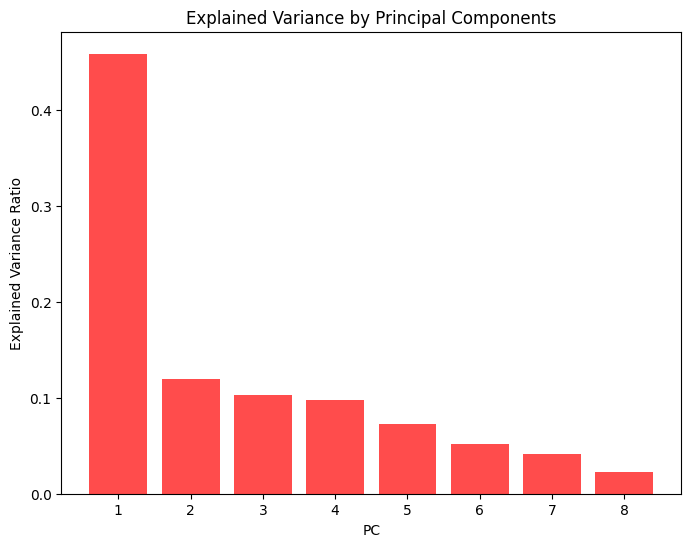

In [130]:
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(explained_variance)+1), explained_variance, color = 'red',alpha=0.7)
plt.ylabel('Explained Variance Ratio')
plt.xlabel('PC')
plt.title('Explained Variance by Principal Components')
plt.show()

In [131]:
pca_components = pd.DataFrame(pca.components_,
                              columns=df_pca_input.columns,
                              index=[f'PC{i+1}' for i in range(pca.n_components_)])
pca_components

,General Health,Exercise in Past 30 Days,Smoking,Shortness of Breath,Hours of Sleeping,BMI Category,Years Since Last Checkup,Cigarettes per Day,Drinks in Last 30 Days,AvgYearlyHDMort100k,AvgYearlyCovidRate
PC1,0.414084,0.419939,-0.378516,0.147667,0.138348,-0.370108,0.152914,-0.310489,0.240283,-0.390555,-0.030505
PC2,-0.043853,-0.004423,-0.129145,0.291157,-0.586745,-0.124430,-0.333434,-0.051220,0.092602,0.010931,0.643706
PC3,-0.173155,0.039318,0.255483,-0.069636,0.051979,0.076135,0.728198,-0.322969,0.160520,0.135758,0.459429
PC4,0.009814,-0.082745,0.039621,0.715244,0.490901,0.303248,-0.030861,0.260918,0.217310,-0.058726,0.165127
PC5,-0.117158,0.012387,-0.275603,0.300185,0.076337,-0.096940,0.199942,-0.102208,-0.865546,0.010042,0.071657
PC6,-0.012624,-0.103057,-0.259103,-0.497079,0.478964,-0.151306,-0.142092,0.305303,-0.056110,-0.122978,0.539468
PC7,-0.086106,0.059036,0.066868,0.078371,-0.290553,-0.322339,0.427333,0.733473,0.031828,-0.250785,-0.075247
PC8,0.076944,0.011750,0.128579,-0.141858,-0.170190,0.569188,0.010383,-0.052011,-0.171958,-0.751038,0.088910


In [132]:
pca_components.loc['PC1'].sort_values(ascending=False)
#exercise and general health is correlated, mortality data value is negatively correlated

,PC1
Exercise in Past 30 Days,0.419939
General Health,0.414084
Drinks in Last 30 Days,0.240283
Years Since Last Checkup,0.152914
Shortness of Breath,0.147667
Hours of Sleeping,0.138348
AvgYearlyCovidRate,-0.030505
Cigarettes per Day,-0.310489
BMI Category,-0.370108
Smoking,-0.378516


In [133]:
pca_components.loc['PC2'].sort_values(ascending=False)
# Covid average and shortness of breath are correlated! also hours of sleeping

,PC2
AvgYearlyCovidRate,0.643706
Shortness of Breath,0.291157
Drinks in Last 30 Days,0.092602
AvgYearlyHDMort100k,0.010931
Exercise in Past 30 Days,-0.004423
General Health,-0.043853
Cigarettes per Day,-0.051220
BMI Category,-0.124430
Smoking,-0.129145
Years Since Last Checkup,-0.333434


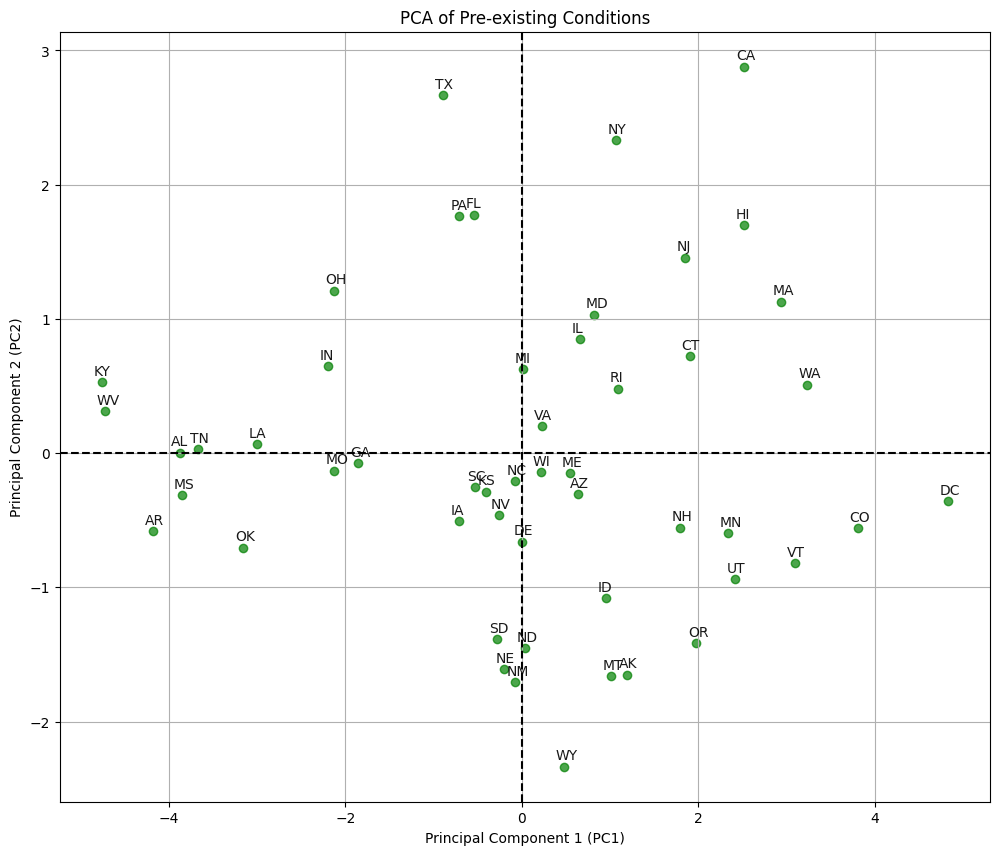

In [134]:
#visualizing the PCs

pc1 = df_pca['PC1']
pc2 = df_pca['PC2']

states = df_unsup['State Abbr.']

plt.figure(figsize=(12, 10))
plt.scatter(pc1, pc2, color = 'green', alpha=0.7)

for i, state in enumerate(df_unsup['State Abbr.']):
    plt.annotate(state, (pc1.iloc[i], pc2.iloc[i]), fontsize=10, alpha=0.9,
                 xytext=(-6, 5), textcoords='offset points') #state annotations

plt.title('PCA of Pre-existing Conditions')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')

#plt.gca().set_facecolor('grey')
plt.axhline(y=0, color='black', linewidth=1.5,linestyle='--')
plt.axvline(x=0, color='black', linewidth=1.5,linestyle='--')

plt.grid()
plt.show()

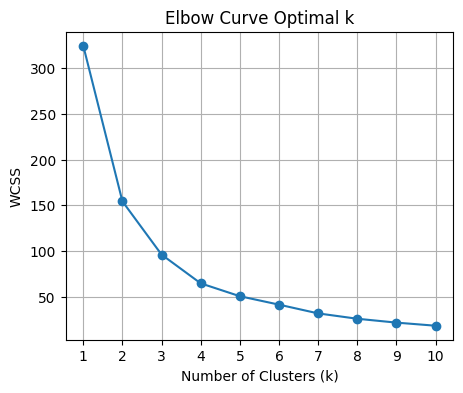

In [135]:
###K Means Clustering
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca[['PC1', 'PC2']])
    wcss.append(kmeans.inertia_)

#elbow curve
plt.figure(figsize=(5, 4))
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Curve Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid()
plt.show()

In [136]:
#Optimal k seems to be 3 or 4
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42,n_init=10)
df_pca['KM_Cluster'] = kmeans.fit_predict(df_pca[['PC1', 'PC2']])
df_pca[['PC1', 'PC2', 'KM_Cluster']].head()

,PC1,PC2,KM_Cluster
0,1.196258,-1.649686,3
1,-3.879468,0.003232,0
2,-4.181443,-0.584003,0
3,0.637193,-0.303453,3
4,2.521609,2.878868,1


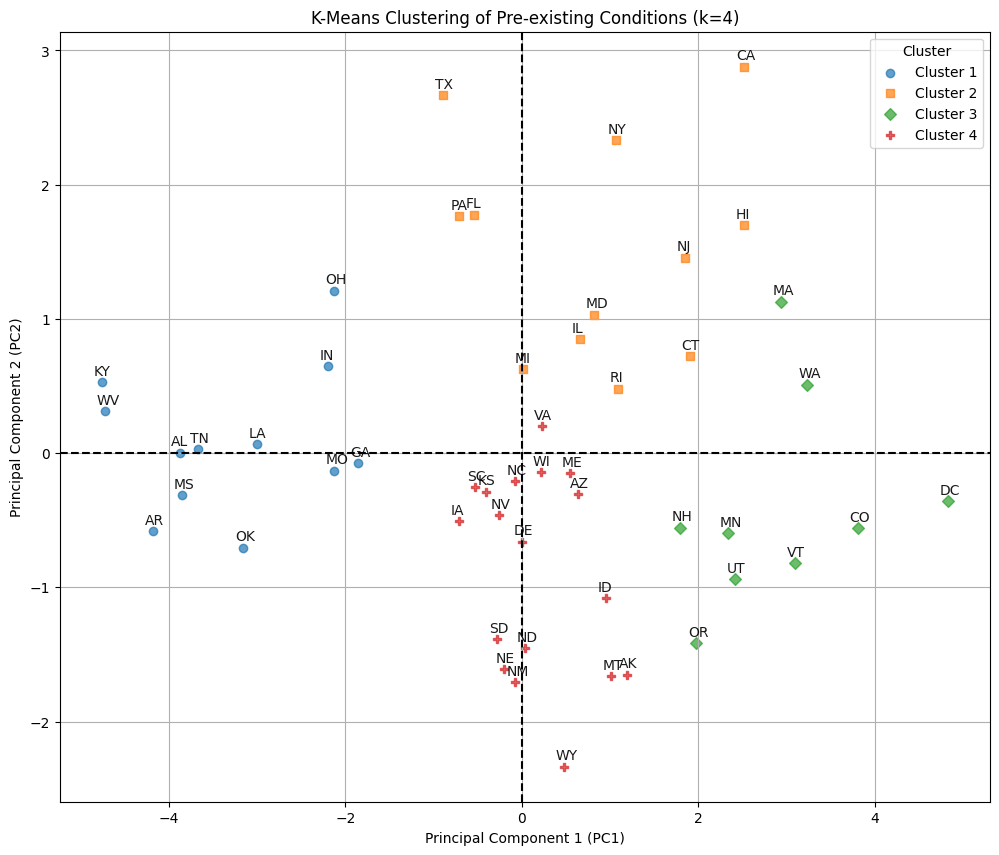

In [137]:
markers = ['o', 's', 'D', 'P', 'X']
plt.figure(figsize=(12, 10))

for cluster in range(optimal_k):
    cluster_data = df_pca[df_pca['KM_Cluster'] == cluster]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                marker=markers[cluster % len(markers)],
                alpha=0.7, label=f'Cluster {cluster+1}')

for i, state in enumerate(df_unsup['State Abbr.']):
    plt.annotate(state, (pc1.iloc[i], pc2.iloc[i]), fontsize=10, alpha=0.9,
                 xytext=(-6, 5), textcoords='offset points')

plt.title(f'K-Means Clustering of Pre-existing Conditions (k={optimal_k})')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.grid()


plt.legend(title='Cluster', loc='upper right')
plt.show()

In [138]:
cluster_proportions = df_pca['KM_Cluster'].value_counts(normalize=True) * 100
print(cluster_proportions)

KM_Cluster
3    35.294118
0    23.529412
1    23.529412
2    17.647059
Name: proportion, dtype: float64


In [139]:
#KMEANS evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

silhouette_avg = silhouette_score(df_pca[['PC1', 'PC2']], df_pca['KM_Cluster'])
print(f'Silhouette Score for KMeans {silhouette_avg}')
X_kmeans = df_pca[['PC1', 'PC2']].values
dbi_kmeans = davies_bouldin_score(X_kmeans, df_pca['KM_Cluster'])
print(f"Davies-Bouldin for KMeans {dbi_kmeans}")
ch_index_kmeans = calinski_harabasz_score(X_kmeans, df_pca['KM_Cluster'])
print(f"Calinski-Harabasz for KMeans {ch_index_kmeans}")

Silhouette Score for KMeans 0.44138271482033903
Davies-Bouldin for KMeans 0.7716151625769178
Calinski-Harabasz for KMeans 63.135791584025796


In [140]:
#DBSCAN
from sklearn.cluster import DBSCAN

X = df_pca[['PC1', 'PC2']].values
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

In [141]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_normalized)
df_pca['DBSCAN_Cluster'] = clusters

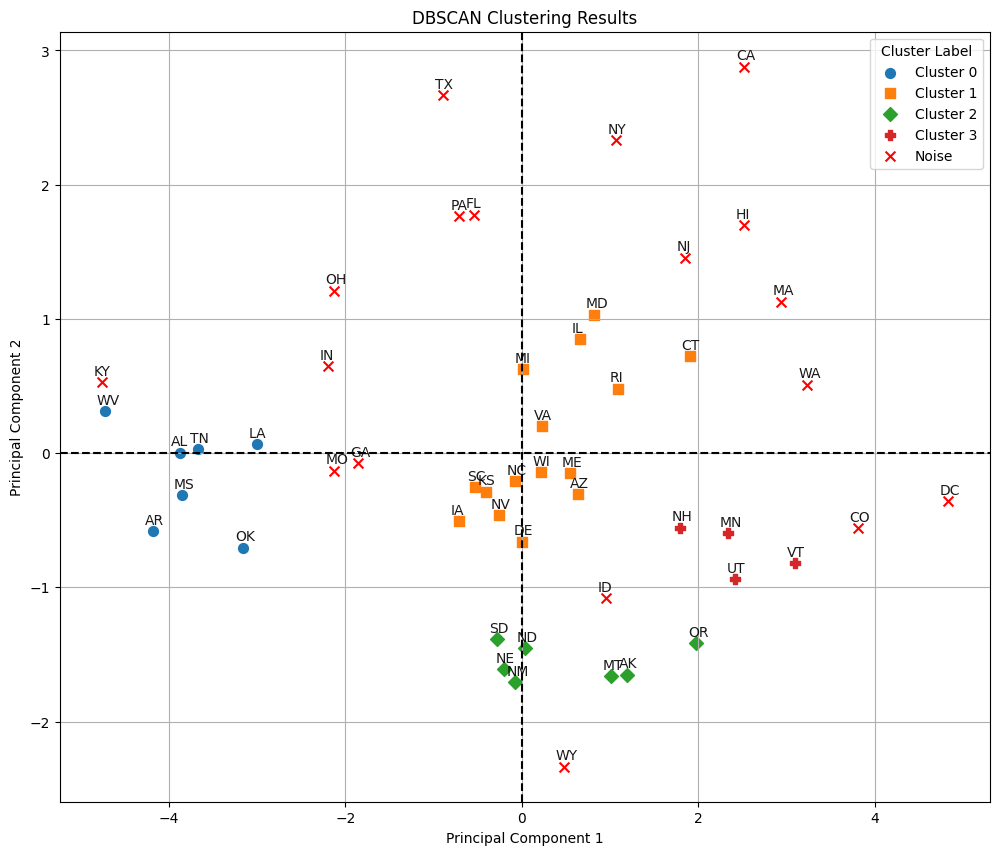

In [142]:
markers = ['o', 's', 'D', 'P', 'X']
noise_marker = 'x'
unique_clusters = set(clusters)

plt.figure(figsize=(12, 10))
for i, cluster in enumerate(unique_clusters):
    if cluster != -1:
        cluster_data = df_pca[df_pca['DBSCAN_Cluster'] == cluster]
        plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                    marker=markers[i % len(markers)],
                    s=50, label=f'Cluster {cluster}')

noise_data = df_pca[df_pca['DBSCAN_Cluster'] == -1]
plt.scatter(noise_data['PC1'], noise_data['PC2'],
            marker=noise_marker, color='red', s=50, label='Noise') #noise label

for i, state in enumerate(df_unsup['State Abbr.']):
    plt.annotate(state, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]),
                 fontsize=10, alpha=0.9, xytext=(-6, 5), textcoords='offset points') #state annotations

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering Results')
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.grid()

plt.legend(title='Cluster Label')
plt.show()

In [143]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f'Number of clusters {n_clusters}')
print(f'Number of noise points {n_noise}')

Number of clusters 4
Number of noise points 18


In [144]:
numeric_columns = df_pca.select_dtypes(include=['number']).columns
cluster_summary = df_pca[numeric_columns].groupby(df_pca['DBSCAN_Cluster']).mean()
cluster_summary

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,KM_Cluster,DBSCAN_Cluster
DBSCAN_Cluster,,,,,,,,,,
-1,0.499188,0.780773,0.292414,-0.077194,0.085758,-0.009783,0.187792,-0.024903,1.166667,-1.0
0,-3.779932,-0.170657,-0.058986,-0.394661,0.229526,-0.169311,-0.265316,-0.364889,0.000000,0.0
1,0.276373,0.061988,-0.505415,0.100061,-0.225858,0.019117,-0.117146,0.154510,2.333333,1.0
2,0.524361,-1.554393,0.643633,0.309023,-0.404508,0.122454,0.044356,0.135140,2.857143,2.0
3,2.414507,-0.727097,-0.443690,0.122008,0.767277,0.054334,-0.019088,-0.065286,2.000000,3.0


In [145]:
#inverse transform from PCA data back to original feature space
df_reconstructed = pd.DataFrame(pca.inverse_transform(df_pca[pca_components.index]),
                                columns=df_unsup.drop(columns=['State Abbr.']).columns)
df_reconstructed['DBSCAN_Cluster'] = df_pca['DBSCAN_Cluster']
cluster_summary_original_features = df_reconstructed.groupby('DBSCAN_Cluster').mean()
cluster_summary_original_features

,General Health,Exercise in Past 30 Days,Smoking,Shortness of Breath,Hours of Sleeping,BMI Category,Years Since Last Checkup,Cigarettes per Day,Drinks in Last 30 Days,AvgYearlyHDMort100k,AvgYearlyCovidRate
DBSCAN_Cluster,,,,,,,,,,,
-1,0.093066,0.236924,-0.229880,0.274322,-0.460213,-0.364591,0.129842,-0.182282,0.158991,-0.168523,0.593479
0,-1.581370,-1.555908,1.338049,-0.701998,-0.544003,1.177244,-0.599094,0.847671,-1.154152,1.853285,-0.174182
1,0.248416,0.077766,-0.168450,0.057221,0.024370,0.026570,-0.445869,0.035317,0.176884,-0.273035,-0.167527
2,0.229304,0.213387,0.279041,-0.396925,1.161617,0.225364,0.979706,-0.106201,0.473947,-0.284292,-0.624084
3,1.015761,0.991632,-1.163762,0.474087,0.898747,-0.913545,0.421649,-0.609742,-0.188417,-0.963504,-0.645466


In [146]:
original_features = df_unsup.drop(columns=['State Abbr.'])
cluster_summary = original_features.groupby(df_pca['DBSCAN_Cluster']).mean()
cluster_summary
#very high Covid rates for the "noise" States, differences in shortness of breath and smoking between all the DBSCAN clusters

,General Health,Exercise in Past 30 Days,Smoking,Shortness of Breath,Hours of Sleeping,BMI Category,Years Since Last Checkup,Cigarettes per Day,Drinks in Last 30 Days,AvgYearlyHDMort100k,AvgYearlyCovidRate
DBSCAN_Cluster,,,,,,,,,,,
-1,3.432377,0.767853,0.513368,7670.333333,6.990388,1.985056,1.386409,5.654016,1.129802,318.824171,151.472019
0,3.223745,0.687873,0.638421,4201.571429,6.981807,2.117167,1.330607,6.624230,0.948117,446.389546,63.096505
1,3.439810,0.762863,0.499699,6813.333333,7.027590,2.028914,1.344088,5.894737,1.141362,315.108765,65.882964
2,3.423734,0.761532,0.550345,5343.142857,7.127411,2.030508,1.455044,5.657979,1.186753,304.740117,14.085418
3,3.548156,0.812409,0.419296,8193.500000,7.100441,1.957433,1.412327,5.363757,1.075765,279.297390,21.338288


In [147]:
#DBSCAN model evaluation
non_noise_indices = df_pca['DBSCAN_Cluster'] != -1
X_non_noise = X_normalized[non_noise_indices]
clusters_non_noise = clusters[non_noise_indices]

silhouette_avg_dbscan = silhouette_score(X_non_noise, clusters_non_noise)
print(f"Silhouette Score for DBSCAN {silhouette_avg_dbscan}")
dbi = davies_bouldin_score(X_non_noise, clusters_non_noise)
print(f"Davies-Bouldin Index for DBSCAN {dbi}")
#lower is better
ch_index = calinski_harabasz_score(X_non_noise, clusters_non_noise)
print(f"Calinski-Harabasz Index for DBSCAN {ch_index}")
#higher is better

Silhouette Score for DBSCAN 0.532097108642448
Davies-Bouldin Index for DBSCAN 0.5731156829238738
Calinski-Harabasz Index for DBSCAN 49.81302173016433


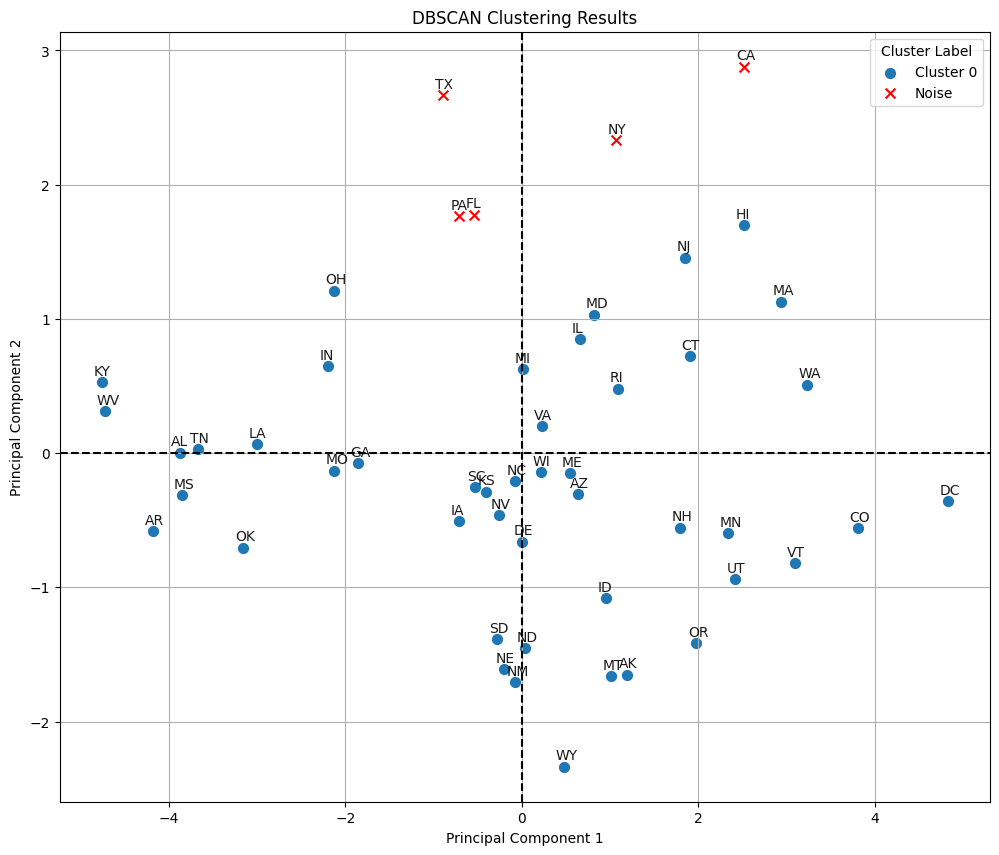

In [148]:
#tried optimizing the hyperparamters but 0.5 and min sample = 5 were the best results.

dbscan = DBSCAN(eps=0.7, min_samples=5)
clusters = dbscan.fit_predict(X_normalized)
df_pca['DBSCAN_Cluster'] = clusters
markers = ['o', 's', 'D', 'P', 'X']
noise_marker = 'x'

unique_clusters = set(clusters)

plt.figure(figsize=(12, 10))
for i, cluster in enumerate(unique_clusters):
    if cluster != -1:
        cluster_data = df_pca[df_pca['DBSCAN_Cluster'] == cluster]
        plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                    marker=markers[i % len(markers)],
                    s=50, label=f'Cluster {cluster}')

noise_data = df_pca[df_pca['DBSCAN_Cluster'] == -1]
plt.scatter(noise_data['PC1'], noise_data['PC2'],
            marker=noise_marker, color='red', s=50, label='Noise')

for i, state in enumerate(df_unsup['State Abbr.']):
    plt.annotate(state, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]),
                 fontsize=10, alpha=0.9, xytext=(-6, 5), textcoords='offset points')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering Results')
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.grid()
plt.legend(title='Cluster Label')
plt.show()

In [149]:
#AGGLOMERATE CLUSTERING - HIERARCHAL

In [150]:
df_pca.head()
#print(df_pca.columns)

,State Abbr.,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,KM_Cluster,DBSCAN_Cluster
0,AK,1.196258,-1.649686,1.473318,-0.268084,-0.282783,-0.403540,1.378065,0.569377,3,0
1,AL,-3.879468,0.003232,-0.576953,-0.720077,1.046749,-0.016437,-1.472936,-0.347766,0,0
2,AR,-4.181443,-0.584003,-0.684210,0.065468,0.332286,0.628262,-0.008936,-0.848416,0,0
3,AZ,0.637193,-0.303453,0.501685,0.372416,0.606043,0.543598,0.329696,0.122882,3,0
4,CA,2.521609,2.878868,2.979830,-0.186707,0.537695,1.848182,-0.502459,0.002956,1,-1


Silhouette Score 0.2275421315580314


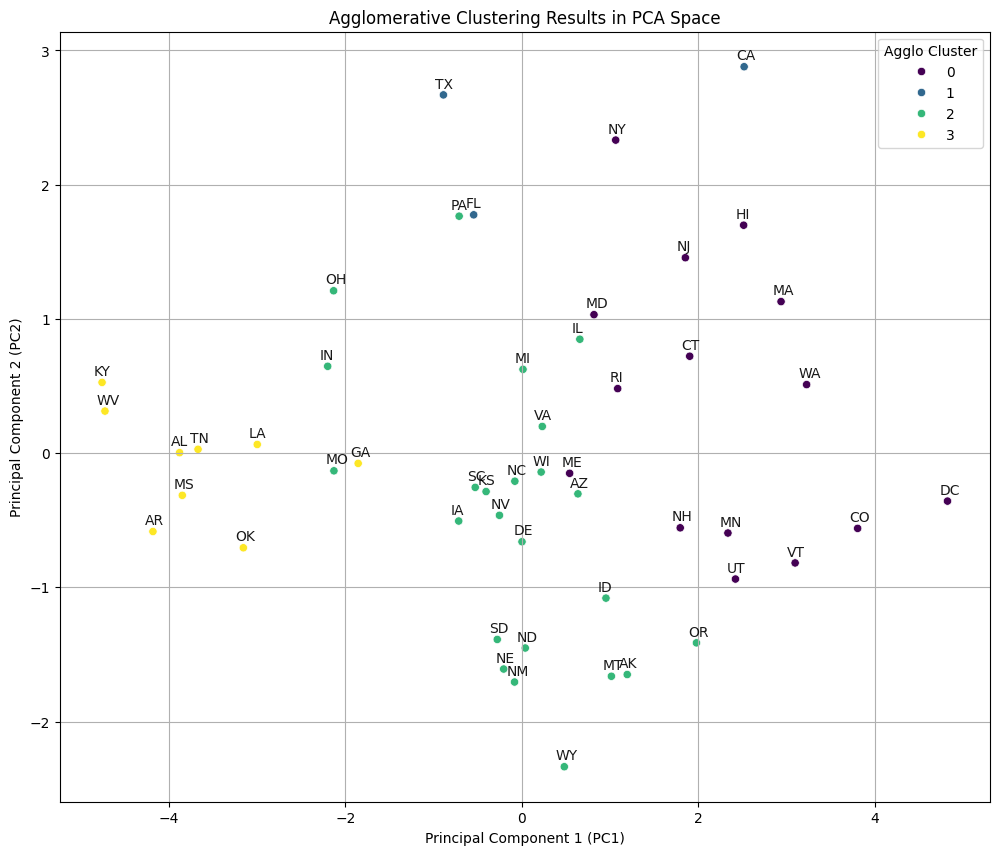

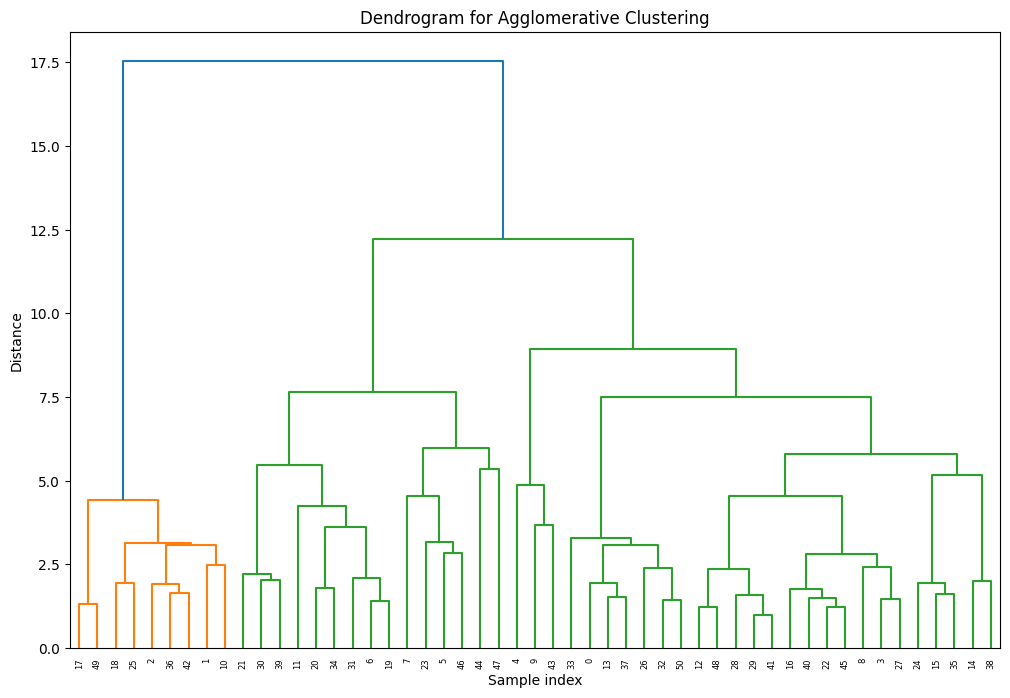

In [151]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

agglo_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df_pca['Agglo_Cluster'] = agglo_model.fit_predict(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster']))

silhouette_avg = silhouette_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), df_pca['Agglo_Cluster'])
print(f"Silhouette Score {silhouette_avg}")

plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', hue='Agglo_Cluster', data=df_pca, palette='viridis', legend='full')

for i, state in enumerate(df_pca['State Abbr.']):
    plt.annotate(state, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]), fontsize=10, alpha=0.9,
                 xytext=(-6, 5), textcoords='offset points')

plt.title('Agglomerative Clustering Results in PCA Space')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Agglo Cluster')
plt.grid()
plt.show()

linkage_matrix = linkage(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), method='ward')
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix) #dendogram diagram
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()


In [152]:
#HYPERPARAMETER TUNING for Agglomerative

for k in range(2, 10):
    agglo_model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agglo_model.fit_predict(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']))
    score = silhouette_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), labels)
    print(f" {k} clusters, Silhouette Score {score}")

 2 clusters, Silhouette Score 0.29358105609326896
 3 clusters, Silhouette Score 0.2122163608110867
 4 clusters, Silhouette Score 0.2275421315580314
 5 clusters, Silhouette Score 0.21739301655080345
 6 clusters, Silhouette Score 0.17920525709293064
 7 clusters, Silhouette Score 0.181554859898111
 8 clusters, Silhouette Score 0.17201678162844544
 9 clusters, Silhouette Score 0.17928925705335091


In [153]:
for method in ['ward', 'complete', 'average', 'single']:
    agglo_model = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = agglo_model.fit_predict(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']))
    score = silhouette_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), labels)
    print(f"Linkage {method}, Silhouette Score {score}")

Linkage ward, Silhouette Score 0.2275421315580314
Linkage complete, Silhouette Score 0.18728090572103293
Linkage average, Silhouette Score 0.19073787552465515
Linkage single, Silhouette Score 0.12756052177799962


In [154]:
for metric in ['euclidean', 'manhattan', 'cosine']:
    agglo_model = AgglomerativeClustering(n_clusters=4, metric=metric, linkage='average')
    labels = agglo_model.fit_predict(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']))
    score1 = silhouette_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), labels)
    score2 = calinski_harabasz_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), labels)
    score3 = davies_bouldin_score(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), labels)
    print(f"Metric {metric}, Silhouette Score {score1}, Davies-Bouldin {score2}, Calinski-Harabasz {score}3")
#higher better
#lower better (does well!)

Metric euclidean, Silhouette Score 0.19073787552465515, Davies-Bouldin 3.395494813148695, Calinski-Harabasz 0.127560521777999623
Metric manhattan, Silhouette Score 0.18732027484984595, Davies-Bouldin 4.636762377719712, Calinski-Harabasz 0.127560521777999623
Metric cosine, Silhouette Score 0.16079664353308418, Davies-Bouldin 11.331394440325047, Calinski-Harabasz 0.127560521777999623


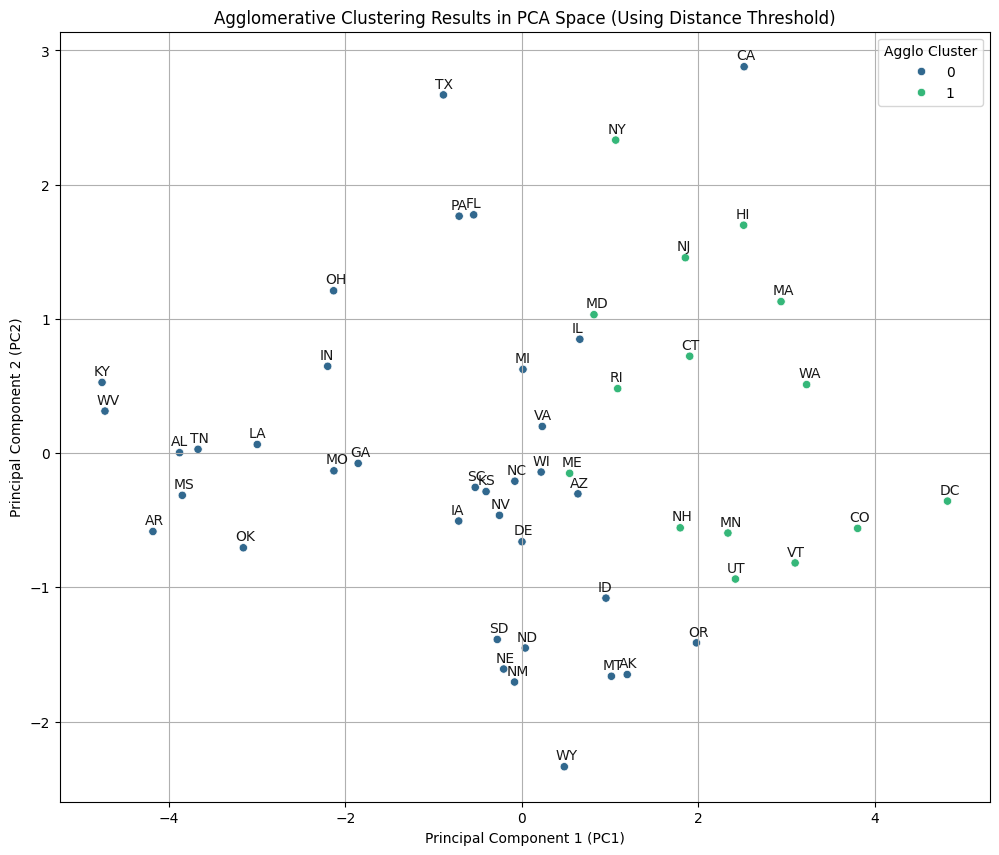

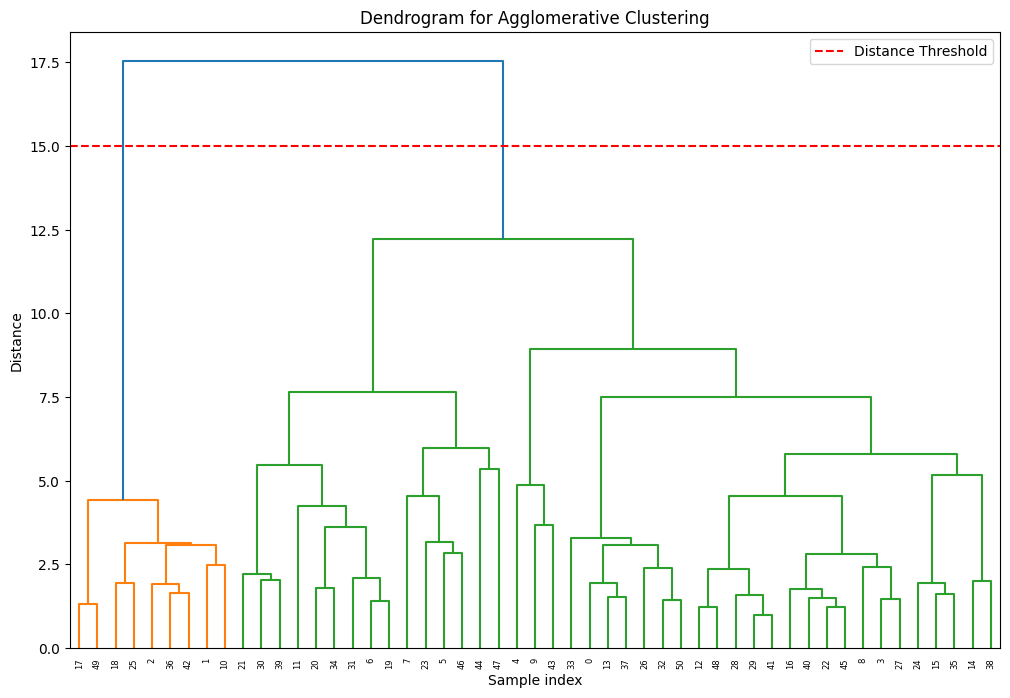

In [155]:
#TRYING TO IMPLEMENT A DISTANCE THRESHOLD FOR CUTOFF, tuning

agglo_model = AgglomerativeClustering(distance_threshold=15,  # Adjust
                                      n_clusters=None,  # Automatic determine number of clusters
                                      metric='euclidean', linkage='ward')

df_pca['Agglo_Cluster'] = agglo_model.fit_predict(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster']))

plt.figure(figsize=(12, 10))
sns.scatterplot(x='PC1', y='PC2', hue='Agglo_Cluster', data=df_pca, palette='viridis', legend='full')

for i, state in enumerate(df_pca['State Abbr.']):
    plt.annotate(state, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]), fontsize=10, alpha=0.9,
                 xytext=(-6, 5), textcoords='offset points') #state names

plt.title('Agglomerative Clustering Results in PCA Space (Using Distance Threshold)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Agglo Cluster')
plt.grid()
plt.show()

linkage_matrix = linkage(df_pca.drop(columns=['State Abbr.', 'KM_Cluster', 'DBSCAN_Cluster', 'Agglo_Cluster']), method='ward')
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, color_threshold=15)  # Color clusters based on threshold
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.axhline(y=15, color='r', linestyle='--', label='Distance Threshold')  # show cut off threshold
plt.legend()
plt.show()


Divisive Clustering Silhouette Score: 0.3883370611950167


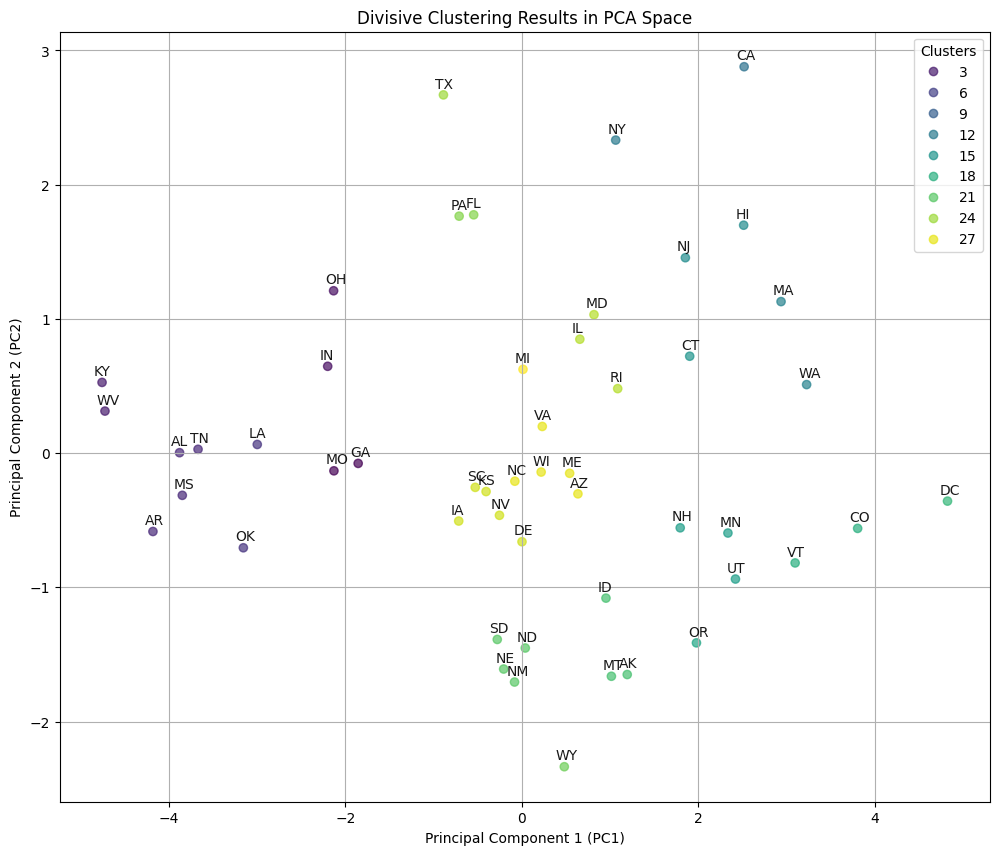

In [156]:
#Divisive Clustering #test if necessary or complicates analysis

from scipy.cluster.hierarchy import linkage, fcluster

df_pca['Initial_Cluster'] = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(df_pca[['PC1', 'PC2']]) #2 is best

def divisive_clustering(data, initial_labels, threshold=0.5):
    clusters = {}
    unique_clusters = np.unique(initial_labels)
    for cluster in unique_clusters:
        cluster_data = data[initial_labels == cluster]
        if len(cluster_data) > 1:
            Z = linkage(cluster_data, method='ward')
            new_labels = fcluster(Z, t=threshold, criterion='distance')
            clusters[cluster] = new_labels

    return clusters

div_clusters = divisive_clustering(df_pca[['PC1', 'PC2']], df_pca['Initial_Cluster'], threshold=0.8) #hyperparameter tuning

for cluster, labels in div_clusters.items():
    df_pca.loc[df_pca['Initial_Cluster'] == cluster, 'Divisive_Cluster'] = labels + (cluster * 10)

num_clusters = df_pca['Divisive_Cluster'].nunique()
if num_clusters < 2:
    raise ValueError("< 2 clusters found, change threshold")

silhouette_avg = silhouette_score(df_pca[['PC1', 'PC2']], df_pca['Divisive_Cluster'])
print(f"Divisive Clustering Silhouette Score: {silhouette_avg}")

plt.figure(figsize=(12, 10))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Divisive_Cluster'], cmap='viridis', alpha=0.7)
plt.title('Divisive Clustering Results in PCA Space')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')

for i, state in enumerate(df_pca['State Abbr.']):
    plt.annotate(state, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]), fontsize=10, alpha=0.9,
                 xytext=(-6, 5), textcoords='offset points')

plt.legend(*scatter.legend_elements(), title="Clusters", loc='upper right')
plt.grid()
plt.show()


In [157]:
num_clusters_divisive = df_pca['Divisive_Cluster'].nunique()
print(f"clusters formed {num_clusters_divisive}")

clusters formed 23


In [158]:
#testing out the clustering for the pre existing conditions not states

df_features = df_unsup.drop(columns=['State Abbr.'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)
df_scaled['State Abbr.'] = df_unsup['State Abbr.'].values


df_melted = pd.melt(df_scaled, id_vars=['State Abbr.'], var_name='Condition', value_name='Score')
df_pivoted = df_melted.pivot_table(index='Condition', columns='State Abbr.', values='Score')
df_pivoted


State Abbr.,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
Condition,,,,,,,,,,,,,,,,,,,,,
AvgYearlyCovidRate,-0.774868,-0.168784,-0.400267,0.284873,4.201528,-0.187002,-0.455061,-0.732945,-0.729948,2.548495,...,-0.701119,0.286753,3.515632,-0.654424,-0.118373,-0.782855,-0.183345,-0.164501,-0.564496,-0.760906
AvgYearlyHDMort100k,-0.965310,2.047724,1.764835,-0.714999,-0.654649,-1.334328,-1.281150,-1.001349,-0.963812,-0.708903,...,-0.114379,1.656545,0.581912,-0.774032,0.199660,-0.243189,-0.924387,-0.149564,0.907481,-0.197166
BMI Category,-0.178407,1.341446,0.732940,-0.420804,-1.337115,-1.770458,-0.627514,-2.913164,0.874056,-0.266723,...,0.856608,0.914130,0.571984,-0.428502,0.234643,-1.756504,-0.586577,0.874902,1.457736,-0.087080
Cigarettes per Day,0.059918,-0.018017,1.531296,-0.095463,-1.809212,-1.094349,-0.260166,-2.581478,-0.121447,1.856175,...,-0.267544,1.650307,-0.382734,-2.531640,-0.290578,0.103766,-0.837972,0.289055,1.531158,0.467651
Drinks in Last 30 Days,0.560993,-2.003308,-1.169134,-0.140974,0.699506,1.176861,0.336755,1.063769,-0.302693,-0.392560,...,0.658675,-0.946452,0.540302,-2.584370,-0.396592,0.673656,0.024301,1.506911,-1.447399,-0.306708
Exercise in Past 30 Days,0.541723,-1.666695,-2.268827,-0.068246,0.997991,1.760302,0.330432,2.371211,0.030170,-0.614854,...,-0.313797,-1.300984,-0.721031,1.498210,0.498349,1.707375,1.596926,0.350450,-1.903931,-0.080138
General Health,0.369883,-1.793435,-2.224180,-0.376401,0.359852,1.341752,1.378004,2.173776,0.288055,-0.495489,...,0.409812,-1.463397,-0.923787,0.974437,0.252367,1.835910,0.526187,0.082547,-2.400289,0.802807
Hours of Sleeping,0.316235,-0.350441,0.292156,0.716825,-0.182401,0.494391,-0.727483,0.369616,-0.023810,0.513064,...,1.459883,-0.781332,-0.530970,-0.048998,0.311954,1.319180,0.961363,0.496651,-1.709982,1.714790
Shortness of Breath,-0.461917,-0.784514,-0.717353,0.211660,0.080148,0.261679,0.228520,-1.183827,-0.996956,0.668017,...,0.128200,-0.723254,1.111167,0.255497,0.192832,0.152648,4.443362,0.403307,-0.630803,-0.921927


In [159]:
df_reset = df_pivoted.reset_index()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_reset.drop(columns='Condition'))

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(data_scaled)
df_reset['DBSCAN_Cluster'] = clusters

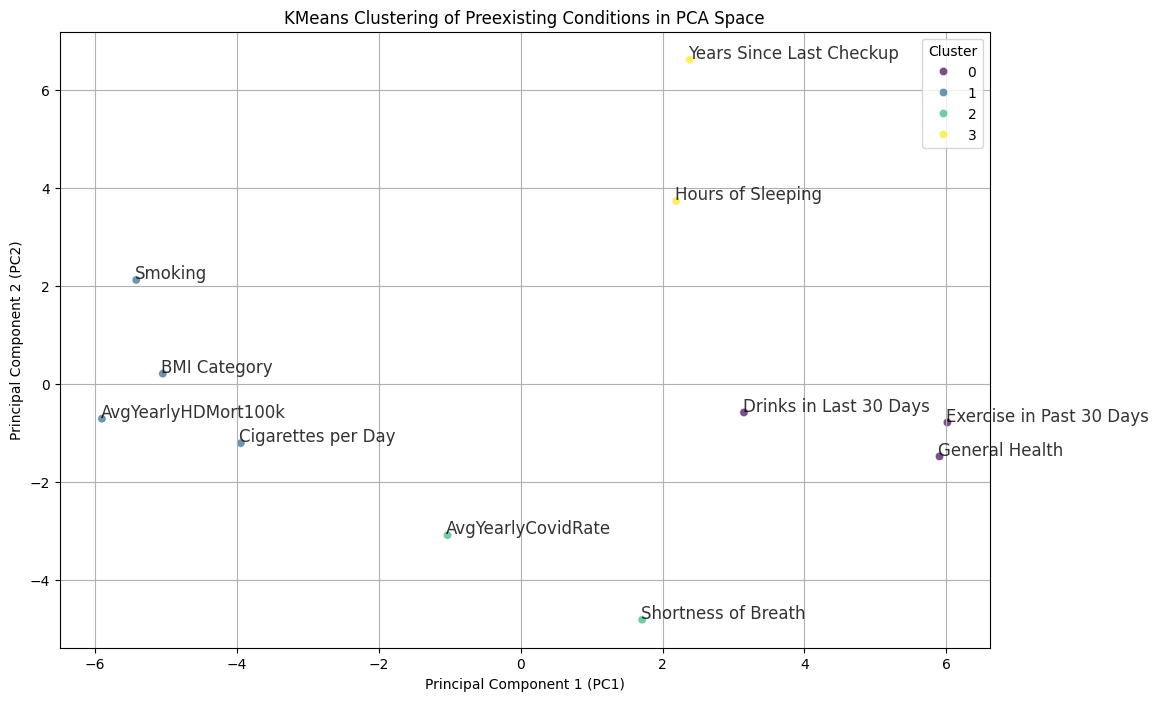

In [160]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
clusters = kmeans.fit_predict(pca_data)

df_pca_clusters = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca_clusters['Condition'] = df_reset['Condition']
df_pca_clusters['Cluster'] = clusters

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='viridis', data=df_pca_clusters, alpha=0.7)

for i, condition in enumerate(df_pca_clusters['Condition']):
    plt.annotate(condition, (df_pca_clusters['PC1'].iloc[i], df_pca_clusters['PC2'].iloc[i]), fontsize=12, alpha=0.8,
                 xytext=(-1, 1), textcoords='offset points')

plt.title('KMeans Clustering of Preexisting Conditions in PCA Space')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid()
plt.legend(title='Cluster', loc='best')
plt.show()